In [11]:
# Here I want to import everything I need for robustness experiments

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = r"C:\Users\Arafat\Desktop\IMA Project"
if project_root not in sys.path:
    sys.path.append(project_root)

from src import config
from src import data_loading
from src import pipelines
from src import features
from src import preprocessing

from src.knn import MyKNNClassifier
from src import evaluation
from src.utils import set_random_seed, SimpleTimer

from skimage import io, util, exposure

from sklearn.preprocessing import StandardScaler

config.make_all_dirs()
set_random_seed(42)

plt.style.use("seaborn-v0_8-whitegrid")


[utils] Random seed set to 42


### load split info and label mapping

In [12]:
# Here I load the split csv and get train/val/test dataframes

df_splits = data_loading.load_splits_csv()
df_train, df_val, df_test = data_loading.get_split_dataframes(df_splits)

print("Train size:", len(df_train))
print("Val size:", len(df_val))
print("Test size:", len(df_test))

# Load label mapping to get class names
label_map_path = os.path.join(config.PROCESSED_DATA_DIR, "label_mapping.csv")
label_map_df = pd.read_csv(label_map_path)
class_names = list(label_map_df["class_name"])
print("Class names:", class_names)


[data_loading] Loading split CSV from C:\Users\Arafat\Desktop\IMA Project\data\processed\splits\split_info.csv
[data_loading] Loaded DataFrame shape: (12444, 3)
[data_loading] Train size: 7466
[data_loading] Val size: 2489
[data_loading] Test size: 2489
Train size: 7466
Val size: 2489
Test size: 2489
Class names: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


### load validation results and find best pipeline + k

In [13]:
# I load the validation results from previous experiments (from notebook knn_advanced_experiments.ipynb)
val_results_path = os.path.join(config.EXPERIMENT_RESULTS_DIR, "per_pipeline_val_results.csv")
df_val_results = pd.read_csv(val_results_path)
print("Validation results shape:", df_val_results.shape)
df_val_results.head()


Validation results shape: (40, 6)


,accuracy,macro_precision,macro_recall,macro_f1,pipeline,k_value
0,0.571716,0.577817,0.572135,0.569001,RawPixels,1
1,0.498192,0.515854,0.498469,0.495947,RawPixels,3
2,0.493773,0.507788,0.494062,0.488444,RawPixels,5
3,0.468059,0.494193,0.468237,0.464351,RawPixels,7
4,0.460024,0.488431,0.460199,0.455492,RawPixels,9


In [14]:
# Find best config (pipeline + k) based on macro F1
idx_best = df_val_results["macro_f1"].idxmax()
best_row = df_val_results.iloc[idx_best]
print("Best validation config overall:")
print(best_row)

best_pipeline_name = best_row["pipeline"]
best_k_value = int(best_row["k_value"])
print("Best pipeline:", best_pipeline_name)
print("Best k:", best_k_value)

# I also define a simple baseline pipeline for comparison
baseline_pipeline_name = "GrayHist"
print("Baseline pipeline:", baseline_pipeline_name)


Best validation config overall:
accuracy             0.964243
macro_precision      0.964391
macro_recall         0.964334
macro_f1             0.964118
pipeline           ColorHists
k_value                     1
Name: 10, dtype: object
Best pipeline: ColorHists
Best k: 1
Baseline pipeline: GrayHist


### function to load & scale features for a pipeline

In [15]:
def load_and_scale_features(pipe_name: str):
    """
    In this function I want to load the precomputed features for a given pipeline
    (train, val, test) and also fit a StandardScaler on train and apply it.
    """
    pipe_folder = os.path.join(config.FEATURES_DIR, pipe_name)
    npz_path = os.path.join(pipe_folder, f"{pipe_name}_features.npz")
    print("Loading features from:", npz_path)

    data = np.load(npz_path)
    feat_train = data["feat_train"]
    feat_val = data["feat_val"]
    feat_test = data["feat_test"]
    y_train = data["y_train"]
    y_val = data["y_val"]
    y_test = data["y_test"]

    scaler = StandardScaler()
    feat_train_scaled = scaler.fit_transform(feat_train)
    feat_val_scaled = scaler.transform(feat_val)
    feat_test_scaled = scaler.transform(feat_test)

    print("Scaled feature shapes:", feat_train_scaled.shape, feat_val_scaled.shape, feat_test_scaled.shape)
    return feat_train_scaled, feat_val_scaled, feat_test_scaled, y_train, y_val, y_test, scaler


### now training MyKNN on clean data (best pipeline) and evaluate on clean test

In [16]:
# Load features for best pipeline
feat_train_best, feat_val_best, feat_test_best, y_train_best, y_val_best, y_test_best, scaler_best = \
    load_and_scale_features(best_pipeline_name)

# Train MyKNN on (train + val) to use maximum clean data
X_train_full = np.vstack([feat_train_best, feat_val_best])
y_train_full = np.concatenate([y_train_best, y_val_best])

print("X_train_full shape:", X_train_full.shape)

my_knn_best_clean = MyKNNClassifier(k_value=best_k_value, distance_metric="l2", use_distance_weight=False)
my_knn_best_clean.fit(X_train_full, y_train_full)

y_test_pred_clean = my_knn_best_clean.predict(feat_test_best)
metrics_clean = evaluation.compute_basic_metrics(y_test_best, y_test_pred_clean)
print("Clean test metrics for BEST pipeline:", best_pipeline_name, "k =", best_k_value)
print(metrics_clean)

evaluation.print_detailed_classification_report(y_test_best, y_test_pred_clean)


Loading features from: C:\Users\Arafat\Desktop\IMA Project\data\processed\features\ColorHists\ColorHists_features.npz
Scaled feature shapes: (7466, 96) (2489, 96) (2489, 96)
X_train_full shape: (9955, 96)
[MyKNN] Stored training data with shape: (9955, 96)
[MyKNN] Predicted 50/2489 samples
[MyKNN] Predicted 100/2489 samples
[MyKNN] Predicted 150/2489 samples
[MyKNN] Predicted 200/2489 samples
[MyKNN] Predicted 250/2489 samples
[MyKNN] Predicted 300/2489 samples
[MyKNN] Predicted 350/2489 samples
[MyKNN] Predicted 400/2489 samples
[MyKNN] Predicted 450/2489 samples
[MyKNN] Predicted 500/2489 samples
[MyKNN] Predicted 550/2489 samples
[MyKNN] Predicted 600/2489 samples
[MyKNN] Predicted 650/2489 samples
[MyKNN] Predicted 700/2489 samples
[MyKNN] Predicted 750/2489 samples
[MyKNN] Predicted 800/2489 samples
[MyKNN] Predicted 850/2489 samples
[MyKNN] Predicted 900/2489 samples
[MyKNN] Predicted 950/2489 samples
[MyKNN] Predicted 1000/2489 samples
[MyKNN] Predicted 1050/2489 samples
[MyKNN]

### robustness to noise in image space 

### functions to add noise & brightness changes

In [17]:
def add_gaussian_noise(temp_img, sigma=0.05):
    """
    In this function I want to add Gaussian noise to an image
    with mean 0 and standard deviation sigma.
    """
    noisy = util.random_noise(temp_img, mode="gaussian", var=(sigma ** 2))
    return noisy


def add_salt_pepper_noise(temp_img, amount=0.05):
    """
    In this function I want to add salt-and-pepper noise to an image.
    amount = proportion of pixels that will be corrupted.
    """
    noisy = util.random_noise(temp_img, mode="s&p", amount=amount)
    return noisy


def change_brightness_contrast(temp_img, gamma=1.0, gain=1.0):
    """
    In this function I want to change brightness and contrast using
    skimage.exposure.adjust_gamma.
    gamma > 1 = darker, gamma < 1 = brighter.
    gain scales the result.
    """
    adjusted = exposure.adjust_gamma(temp_img, gamma=gamma, gain=gain)
    return adjusted


### function to recompute features from noisy test images

In [22]:
import numpy as np
from skimage import exposure
from skimage.color import rgb2hsv
from skimage.feature import local_binary_pattern

from src import preprocessing
from src import filters as my_filters


def build_noisy_features_for_pipeline(df_test_subset, pipeline_name, noise_type="gaussian", noise_level=0.05):
    """
    Here I want to:
    - take test images from df_test_subset
    - apply noise/brightness change in image space
    - compute the SAME kind of features as the chosen pipeline
    - return a feature matrix (num_images x feature_dim)

    This function is used for robustness testing.
    """

    pipe_info = pipelines.PIPELINES[pipeline_name]
    feature_name_list = pipe_info["feature_names"]
    print("Using feature names:", feature_name_list)

    img_paths = df_test_subset["filepath"].tolist()
    num_imgs = len(img_paths)

    def apply_distortion(gray_img):
        # Here I apply the chosen distortion to the grayscale image.
        if noise_type == "gaussian":
            return add_gaussian_noise(gray_img, sigma=noise_level)
        elif noise_type == "s&p":
            return add_salt_pepper_noise(gray_img, amount=noise_level)
        elif noise_type == "brightness_dark":
            return change_brightness_contrast(gray_img, gamma=1.5, gain=1.0)
        elif noise_type == "brightness_bright":
            return change_brightness_contrast(gray_img, gamma=0.7, gain=1.0)
        else:
            return gray_img

    def compute_one_feature_vector_from_noisy_gray(noisy_gray, feature_names):
        """
        Here I compute the feature vector for one image, using the pipeline's feature list.
        """
        temp_vecs = []

        for fname in feature_names:

            if fname == "gray_hist":
                # grayscale histogram
                hist_vals, _ = exposure.histogram(noisy_gray, nbins=32)
                hist_vals = hist_vals.astype(float)
                if hist_vals.sum() > 0:
                    hist_vals /= hist_vals.sum()
                temp_vecs.append(hist_vals.astype(np.float32))

            elif fname == "rgb_hist":
                num_bins = 16
            
                temp_rgb = np.stack([noisy_gray, noisy_gray, noisy_gray], axis=-1)
                hist_list = []
                for ch in range(3):
                    h, _ = exposure.histogram(temp_rgb[:, :, ch], nbins=num_bins)
                    h = h.astype(float)
                    if h.sum() > 0:
                        h /= h.sum()
                    hist_list.append(h)
                temp_vecs.append(np.concatenate(hist_list).astype(np.float32))
            

            elif fname == "hsv_hist":
                num_bins = 16
            
                temp_rgb = np.stack([noisy_gray, noisy_gray, noisy_gray], axis=-1)
                temp_hsv = rgb2hsv(temp_rgb)
                hist_list = []
                for ch in range(3):
                    h, _ = exposure.histogram(temp_hsv[:, :, ch], nbins=num_bins)
                    h = h.astype(float)
                    if h.sum() > 0:
                        h /= h.sum()
                    hist_list.append(h)
                temp_vecs.append(np.concatenate(hist_list).astype(np.float32))


            elif fname == "sobel_hist":
                sobel_img = my_filters.sobel_magnitude(noisy_gray)
                hist_vals, _ = exposure.histogram(sobel_img, nbins=32)
                hist_vals = hist_vals.astype(float)
                if hist_vals.sum() > 0:
                    hist_vals /= hist_vals.sum()
                temp_vecs.append(hist_vals.astype(np.float32))

            elif fname == "lbp_hist":
                lbp_img = local_binary_pattern(noisy_gray, P=16, R=2, method="uniform")
                lbp_vals = lbp_img.ravel()
                n_bins = int(lbp_vals.max() + 2)
                hist_vals, _ = np.histogram(lbp_vals, bins=n_bins, range=(0, n_bins), density=True)
                temp_vecs.append(hist_vals.astype(np.float32))

            elif fname == "fft_radial":
                radial = my_filters.fft_radial_energy(noisy_gray, num_bins=8)
                temp_vecs.append(radial.astype(np.float32))

            elif fname == "fft_low_patch":
                patch = my_filters.fft_low_freq_patch(noisy_gray, patch_size=15)
                temp_vecs.append(patch.flatten().astype(np.float32))

            elif fname == "dct_low_block":
                block = my_filters.dct_low_freq_block(noisy_gray, block_size=8)
                temp_vecs.append(block.flatten().astype(np.float32))

            elif fname == "shape_morphology":
                shape_vec = my_filters.shape_features_from_binary(noisy_gray)
                temp_vecs.append(shape_vec.astype(np.float32))

            else:
                print("feature type not implemented for noisy version:", fname)

        # If nothing matched i need to return None so caller can handle it
        if len(temp_vecs) == 0:
            return None

        return np.concatenate(temp_vecs)


    first_path = img_paths[0]
    temp_img = preprocessing.load_image_as_float(first_path)
    temp_img = preprocessing.resize_image(temp_img)
    temp_gray = preprocessing.to_grayscale(temp_img)
    temp_noisy = apply_distortion(temp_gray)

    first_vec = compute_one_feature_vector_from_noisy_gray(temp_noisy, feature_name_list)
    if first_vec is None:
        raise RuntimeError("No features were created. need to check pipeline feature names vs this function support.")

    feat_dim = first_vec.shape[0]
    print("Noisy feature dimension:", feat_dim)


    feat_matrix = np.zeros((num_imgs, feat_dim), dtype=np.float32)

    for idx, path in enumerate(img_paths):
        temp_img = preprocessing.load_image_as_float(path)
        temp_img = preprocessing.resize_image(temp_img)
        temp_gray = preprocessing.to_grayscale(temp_img)
        temp_noisy = apply_distortion(temp_gray)

        vec = compute_one_feature_vector_from_noisy_gray(temp_noisy, feature_name_list)
        if vec is None:
            # fallback to zeros should not happen, but I don't want crash
            vec = np.zeros(feat_dim, dtype=np.float32)

        feat_matrix[idx, :] = vec

        if (idx + 1) % 200 == 0 or (idx + 1) == num_imgs:
            print(f"Built noisy features for {idx+1}/{num_imgs}")

    return feat_matrix


### gaussian noise robustness

In [23]:
# Here I test how performance drops when I add Gaussian noise with different sigma values.
noise_sigmas = [0.0, 0.02, 0.05, 0.1, 0.15]

results_noise_gaussian = []

# I already have scaler_best fit on clean features, so I reuse it
df_test_subset = df_test.copy()
y_test_array = np.array(df_test_subset["label"])

# So here I just reuse y_test_best.

for sigma in noise_sigmas:
    print("\nGaussian noise sigma", sigma)
    if sigma == 0.0:
        # this is just the clean case, I already have feat_test_best
        feat_test_noisy = feat_test_best.copy()
    else:
        with SimpleTimer(message=f"Building noisy features (sigma={sigma})"):
            feat_test_noisy_raw = build_noisy_features_for_pipeline(df_test_subset, best_pipeline_name,
                                                                    noise_type="gaussian", noise_level=sigma)
            # scale with the same scaler as clean train
            feat_test_noisy = scaler_best.transform(feat_test_noisy_raw)

    y_pred = my_knn_best_clean.predict(feat_test_noisy)
    metrics_gauss = evaluation.compute_basic_metrics(y_test_best, y_pred)
    metrics_gauss["noise_type"] = "gaussian"
    metrics_gauss["sigma"] = sigma
    results_noise_gaussian.append(metrics_gauss)
    print("Metrics:", metrics_gauss)

df_gauss = pd.DataFrame(results_noise_gaussian)
df_gauss



=== Gaussian noise sigma = 0.0 ===
[MyKNN] Predicted 50/2489 samples
[MyKNN] Predicted 100/2489 samples
[MyKNN] Predicted 150/2489 samples
[MyKNN] Predicted 200/2489 samples
[MyKNN] Predicted 250/2489 samples
[MyKNN] Predicted 300/2489 samples
[MyKNN] Predicted 350/2489 samples
[MyKNN] Predicted 400/2489 samples
[MyKNN] Predicted 450/2489 samples
[MyKNN] Predicted 500/2489 samples
[MyKNN] Predicted 550/2489 samples
[MyKNN] Predicted 600/2489 samples
[MyKNN] Predicted 650/2489 samples
[MyKNN] Predicted 700/2489 samples
[MyKNN] Predicted 750/2489 samples
[MyKNN] Predicted 800/2489 samples
[MyKNN] Predicted 850/2489 samples
[MyKNN] Predicted 900/2489 samples
[MyKNN] Predicted 950/2489 samples
[MyKNN] Predicted 1000/2489 samples
[MyKNN] Predicted 1050/2489 samples
[MyKNN] Predicted 1100/2489 samples
[MyKNN] Predicted 1150/2489 samples
[MyKNN] Predicted 1200/2489 samples
[MyKNN] Predicted 1250/2489 samples
[MyKNN] Predicted 1300/2489 samples
[MyKNN] Predicted 1350/2489 samples
[MyKNN] Pred

,accuracy,macro_precision,macro_recall,macro_f1,noise_type,sigma
0,0.969867,0.969914,0.969912,0.969893,gaussian,0.00
1,0.229008,0.266419,0.229193,0.201380,gaussian,0.02
2,0.224588,0.206129,0.224069,0.172845,gaussian,0.05
3,0.256328,0.213667,0.255521,0.197400,gaussian,0.10
4,0.253114,0.223699,0.252077,0.138575,gaussian,0.15


### visualizing gaussian noise robustness

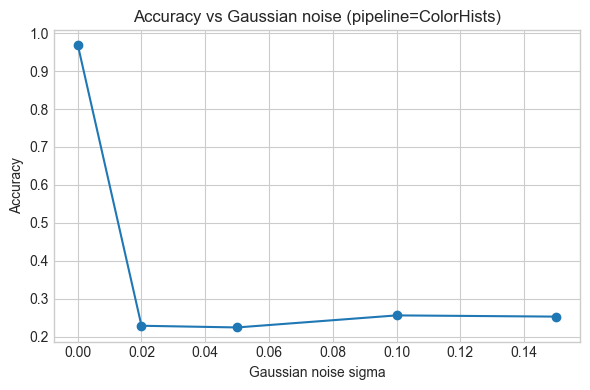

In [24]:
plt.figure(figsize=(6,4))
plt.plot(df_gauss["sigma"], df_gauss["accuracy"], marker="o")
plt.title(f"Accuracy vs Gaussian noise (pipeline={best_pipeline_name})")
plt.xlabel("Gaussian noise sigma")
plt.ylabel("Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()


### salt & pepper noise robustness

In [25]:
# Same idea but for salt-and-pepper noise

noise_amounts = [0.0, 0.02, 0.05, 0.1, 0.2]
results_noise_sp = []

for amt in noise_amounts:
    print("\n=== Salt & Pepper noise amount =", amt, "===")
    if amt == 0.0:
        feat_test_noisy = feat_test_best.copy()
    else:
        with SimpleTimer(message=f"Building noisy features (s&p amount={amt})"):
            feat_test_noisy_raw = build_noisy_features_for_pipeline(df_test_subset, best_pipeline_name,
                                                                    noise_type="s&p", noise_level=amt)
            feat_test_noisy = scaler_best.transform(feat_test_noisy_raw)

    y_pred = my_knn_best_clean.predict(feat_test_noisy)
    metrics_sp = evaluation.compute_basic_metrics(y_test_best, y_pred)
    metrics_sp["noise_type"] = "s&p"
    metrics_sp["amount"] = amt
    results_noise_sp.append(metrics_sp)
    print("Metrics:", metrics_sp)

df_sp = pd.DataFrame(results_noise_sp)
df_sp



=== Salt & Pepper noise amount = 0.0 ===
[MyKNN] Predicted 50/2489 samples
[MyKNN] Predicted 100/2489 samples
[MyKNN] Predicted 150/2489 samples
[MyKNN] Predicted 200/2489 samples
[MyKNN] Predicted 250/2489 samples
[MyKNN] Predicted 300/2489 samples
[MyKNN] Predicted 350/2489 samples
[MyKNN] Predicted 400/2489 samples
[MyKNN] Predicted 450/2489 samples
[MyKNN] Predicted 500/2489 samples
[MyKNN] Predicted 550/2489 samples
[MyKNN] Predicted 600/2489 samples
[MyKNN] Predicted 650/2489 samples
[MyKNN] Predicted 700/2489 samples
[MyKNN] Predicted 750/2489 samples
[MyKNN] Predicted 800/2489 samples
[MyKNN] Predicted 850/2489 samples
[MyKNN] Predicted 900/2489 samples
[MyKNN] Predicted 950/2489 samples
[MyKNN] Predicted 1000/2489 samples
[MyKNN] Predicted 1050/2489 samples
[MyKNN] Predicted 1100/2489 samples
[MyKNN] Predicted 1150/2489 samples
[MyKNN] Predicted 1200/2489 samples
[MyKNN] Predicted 1250/2489 samples
[MyKNN] Predicted 1300/2489 samples
[MyKNN] Predicted 1350/2489 samples
[MyKNN

,accuracy,macro_precision,macro_recall,macro_f1,noise_type,amount
0,0.969867,0.969914,0.969912,0.969893,s&p,0.00
1,0.240659,0.253251,0.240417,0.226510,s&p,0.02
2,0.239454,0.251270,0.239232,0.226937,s&p,0.05
3,0.240659,0.248502,0.240451,0.229811,s&p,0.10
4,0.245882,0.257654,0.245795,0.241048,s&p,0.20


### visualizing S&P noise robustness

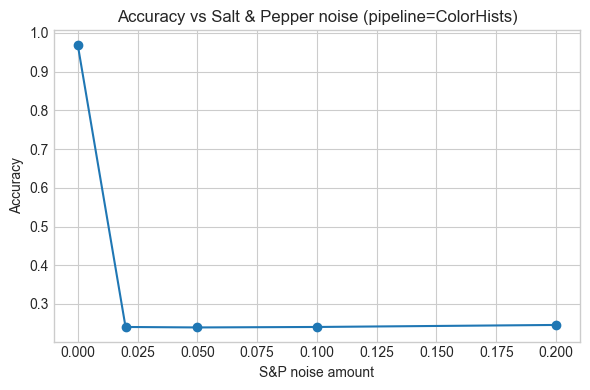

In [26]:
plt.figure(figsize=(6,4))
plt.plot(df_sp["amount"], df_sp["accuracy"], marker="o")
plt.title(f"Accuracy vs Salt & Pepper noise (pipeline={best_pipeline_name})")
plt.xlabel("S&P noise amount")
plt.ylabel("Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()


### sensitivity to brightness and contrast changes test
### darker and brighter test images

In [27]:
# Here I just do two cases: darker and brighter.
brightness_cases = ["brightness_dark", "brightness_bright"]
results_brightness = []

for case in brightness_cases:
    print("\n=== Case:", case, "===")
    with SimpleTimer(message=f"Building features for {case}"):
        feat_test_noisy_raw = build_noisy_features_for_pipeline(df_test_subset, best_pipeline_name,
                                                                noise_type=case, noise_level=0.0)
        feat_test_noisy = scaler_best.transform(feat_test_noisy_raw)

    y_pred = my_knn_best_clean.predict(feat_test_noisy)
    metrics_case = evaluation.compute_basic_metrics(y_test_best, y_pred)
    metrics_case["case"] = case
    results_brightness.append(metrics_case)
    print("Metrics:", metrics_case)

df_bright = pd.DataFrame(results_brightness)
df_bright



=== Case: brightness_dark ===
[timer] Starting: Building features for brightness_dark
Using feature names: ['rgb_hist', 'hsv_hist']
Noisy feature dimension: 96
Built noisy features for 200/2489
Built noisy features for 400/2489
Built noisy features for 600/2489
Built noisy features for 800/2489
Built noisy features for 1000/2489
Built noisy features for 1200/2489
Built noisy features for 1400/2489
Built noisy features for 1600/2489
Built noisy features for 1800/2489
Built noisy features for 2000/2489
Built noisy features for 2200/2489
Built noisy features for 2400/2489
Built noisy features for 2489/2489
[timer] Building features for brightness_dark: 58.38 seconds
[MyKNN] Predicted 50/2489 samples
[MyKNN] Predicted 100/2489 samples
[MyKNN] Predicted 150/2489 samples
[MyKNN] Predicted 200/2489 samples
[MyKNN] Predicted 250/2489 samples
[MyKNN] Predicted 300/2489 samples
[MyKNN] Predicted 350/2489 samples
[MyKNN] Predicted 400/2489 samples
[MyKNN] Predicted 450/2489 samples
[MyKNN] Predi

,accuracy,macro_precision,macro_recall,macro_f1,case
0,0.199277,0.157741,0.198748,0.151194,brightness_dark
1,0.265167,0.154827,0.266350,0.137342,brightness_bright


### now comparing clean vs dark vs bright

In [28]:
# I build a small table comparing accuracy, macro F1 etc.

summary_rows = []

clean_row = {
    "case": "clean",
    "accuracy": metrics_clean["accuracy"],
    "macro_f1": metrics_clean["macro_f1"],
}
summary_rows.append(clean_row)

for _, r in df_bright.iterrows():
    summary_rows.append({"case": r["case"], "accuracy": r["accuracy"], "macro_f1": r["macro_f1"]})

df_light_summary = pd.DataFrame(summary_rows)
df_light_summary


,case,accuracy,macro_f1
0,clean,0.969867,0.969893
1,brightness_dark,0.199277,0.151194
2,brightness_bright,0.265167,0.137342


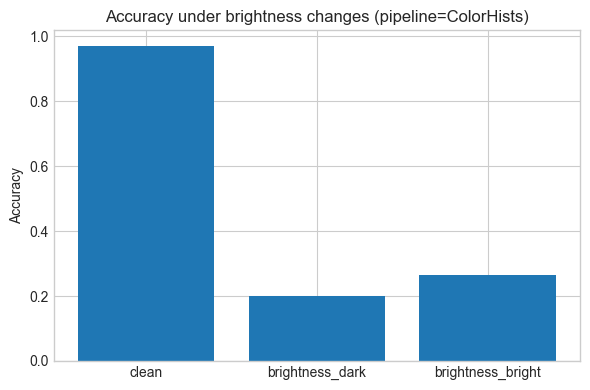

In [29]:
# visualizing

plt.figure(figsize=(6,4))
plt.bar(df_light_summary["case"], df_light_summary["accuracy"])
plt.title(f"Accuracy under brightness changes (pipeline={best_pipeline_name})")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()


### training size experiment

In [30]:
train_fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
results_train_size = []

for frac in train_fractions:
    print("\n=== Training fraction =", frac, "===")
    # sample a subset of training indices
    num_train = X_train_full.shape[0]
    num_take = int(num_train * frac)
    idxs = np.random.choice(num_train, size=num_take, replace=False)

    X_train_sub = X_train_full[idxs]
    y_train_sub = y_train_full[idxs]

    print("Using", num_take, "samples for training")

    my_knn_sub = MyKNNClassifier(k_value=best_k_value, distance_metric="l2", use_distance_weight=False)
    my_knn_sub.fit(X_train_sub, y_train_sub)
    y_test_pred_sub = my_knn_sub.predict(feat_test_best)

    metrics_sub = evaluation.compute_basic_metrics(y_test_best, y_test_pred_sub)
    metrics_sub["train_fraction"] = frac
    results_train_size.append(metrics_sub)
    print("Metrics:", metrics_sub)

df_train_size = pd.DataFrame(results_train_size)
df_train_size



=== Training fraction = 0.2 ===
Using 1991 samples for training
[MyKNN] Stored training data with shape: (1991, 96)
[MyKNN] Predicted 50/2489 samples
[MyKNN] Predicted 100/2489 samples
[MyKNN] Predicted 150/2489 samples
[MyKNN] Predicted 200/2489 samples
[MyKNN] Predicted 250/2489 samples
[MyKNN] Predicted 300/2489 samples
[MyKNN] Predicted 350/2489 samples
[MyKNN] Predicted 400/2489 samples
[MyKNN] Predicted 450/2489 samples
[MyKNN] Predicted 500/2489 samples
[MyKNN] Predicted 550/2489 samples
[MyKNN] Predicted 600/2489 samples
[MyKNN] Predicted 650/2489 samples
[MyKNN] Predicted 700/2489 samples
[MyKNN] Predicted 750/2489 samples
[MyKNN] Predicted 800/2489 samples
[MyKNN] Predicted 850/2489 samples
[MyKNN] Predicted 900/2489 samples
[MyKNN] Predicted 950/2489 samples
[MyKNN] Predicted 1000/2489 samples
[MyKNN] Predicted 1050/2489 samples
[MyKNN] Predicted 1100/2489 samples
[MyKNN] Predicted 1150/2489 samples
[MyKNN] Predicted 1200/2489 samples
[MyKNN] Predicted 1250/2489 samples
[My

,accuracy,macro_precision,macro_recall,macro_f1,train_fraction
0,0.922861,0.922336,0.923067,0.922261,0.2
1,0.949779,0.949885,0.949905,0.949666,0.4
2,0.962234,0.962187,0.962307,0.962191,0.6
3,0.966653,0.966642,0.966713,0.966638,0.8
4,0.969867,0.969914,0.969912,0.969893,1.0


### visualizing training size vs performance

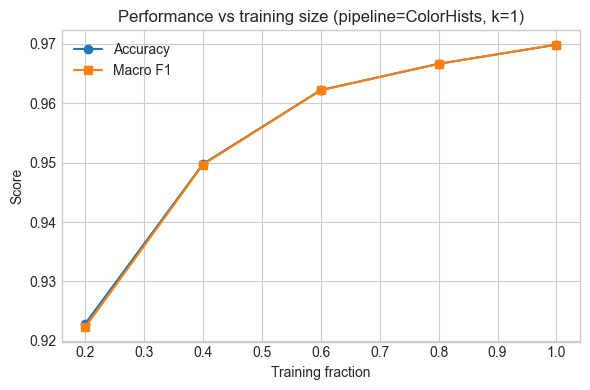

In [31]:
plt.figure(figsize=(6,4))
plt.plot(df_train_size["train_fraction"], df_train_size["accuracy"], marker="o", label="Accuracy")
plt.plot(df_train_size["train_fraction"], df_train_size["macro_f1"], marker="s", label="Macro F1")
plt.title(f"Performance vs training size (pipeline={best_pipeline_name}, k={best_k_value})")
plt.xlabel("Training fraction")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### saving the results

In [32]:
robustness_folder = config.EXPERIMENT_RESULTS_DIR
if not os.path.exists(robustness_folder):
    os.makedirs(robustness_folder, exist_ok=True)

df_gauss.to_csv(os.path.join(robustness_folder, "robustness_gaussian_noise.csv"), index=False)
df_sp.to_csv(os.path.join(robustness_folder, "robustness_salt_pepper.csv"), index=False)
df_bright.to_csv(os.path.join(robustness_folder, "robustness_brightness.csv"), index=False)
df_train_size.to_csv(os.path.join(robustness_folder, "sensitivity_train_size.csv"), index=False)

print("Saved robustness/sensitivity CSVs in:", robustness_folder)


Saved robustness/sensitivity CSVs in: C:\Users\Arafat\Desktop\IMA Project\experiments\results
